Training Linear Regression Model...

Mean Squared Error (MSE): 0.6589
R-squared Score (Accuracy Metric): 49.72%

Visualization saved as 'regression_performance.png'


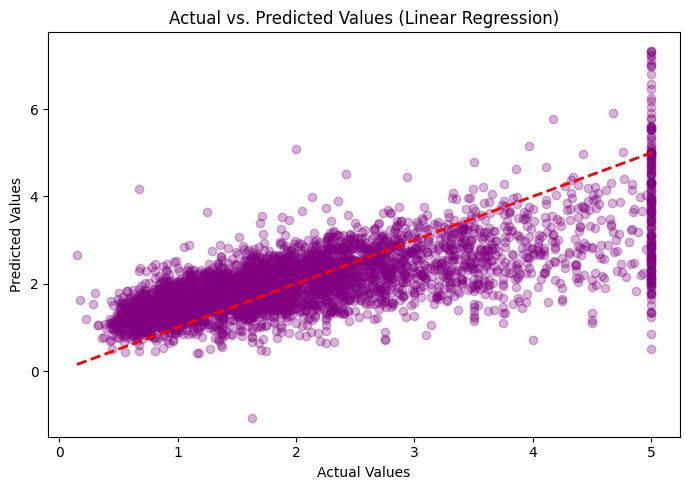

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
# Fetching a standard regression dataset (California Housing)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # The continuous numerical target

# Let's use a subset of features for simplicity
X = df[['MedInc', 'HouseAge', 'AveRooms']]  # Income, Age, Rooms
y = df['MedHouseVal']

# Split into 80% Training and 20% Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. TRAIN THE MODEL (Linear Regression)
# ==========================================
print("Training Linear Regression Model...")
model = LinearRegression()
model.fit(X_train, y_train)

# ==========================================
# 3. EVALUATE THE MODEL
# ==========================================
y_pred = model.predict(X_test)

# Calculate evaluation metrics for regression
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.4f}")
print(f"R-squared Score (Accuracy Metric): {r2 * 100:.2f}%")

# ==========================================
# 4. VISUALIZE PERFORMANCE (Prediction Plot)
# ==========================================
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Perfect fit line

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values (Linear Regression)")
plt.tight_layout()

# Save the visualization to submit along with your work
plt.savefig('regression_performance.png', dpi=300)
print("\nVisualization saved as 'regression_performance.png'")
plt.show()